In [1]:
import util
import processUtil

from skimage import filters, morphology, measure, exposure
from skimage.segmentation import find_boundaries
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import joblib

# Get data

In [2]:
# Get data
file_path = "aliveData.joblib"

if os.path.exists(file_path):
    data = joblib.load(file_path)
else:
    data = util.getAliveData()
    joblib.dump(data, file_path)

# Get Mask (Segmentation)

In [3]:
# get masks and corrects for all alive data
# masks_corrected: index 0 = mask, index 1 = corrected
file_path = "maskCorrect.joblib"

if os.path.exists(file_path):
    masks_corrected = joblib.load(file_path)
else:
    masks_corrected = []
    for i in range(len(data)):
        masks_corrected.append(processUtil.getSegments(data[i]))
    joblib.dump(masks_corrected, file_path)

Image: pos_226


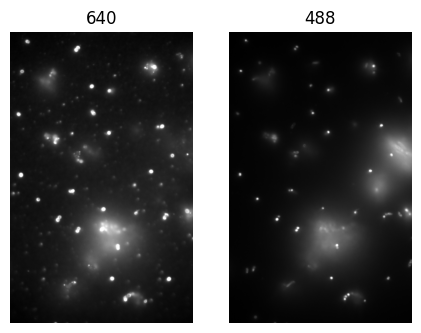

In [4]:
util.printImg(data[133], "gray")

Image: pos_226


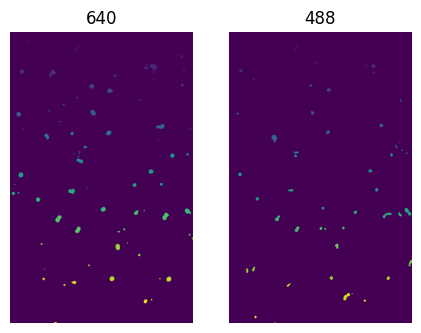

In [5]:
print(f"Image: {data[133][3]}")
util.printMask(masks_corrected[133])

# Get Morphological Features

In [6]:
# get stats of each bateria for each img data
# stats: label, area, x, y, major_length, minor_length
file_path = "bateriaStat.joblib"

if os.path.exists(file_path):
    stats = joblib.load(file_path)
else:
    stats = []
    for i in range(len(data)):
        stats.append(processUtil.getStats(masks_corrected[i], data[i]))
    joblib.dump(stats, file_path)

In [7]:
print(stats[133][0])

    label   area           x           y  major_length  minor_length
0       1   89.0   40.370787   24.382022     12.152977      9.349376
1       2  155.0  156.264516   41.348387     18.354933     10.902920
2       3    3.0  397.666667   52.333333      2.309401      1.333333
3       4    7.0  391.571429   54.285714      5.672452      1.560618
4       5   41.0  400.829268   59.365854      8.744633      6.164138
..    ...    ...         ...         ...           ...           ...
69     70   60.0  149.483333  588.533333     11.232495      7.095222
70     71   17.0  126.882353  594.411765      5.181900      4.041201
71     72   61.0  316.442623  632.704918      9.908347      7.825042
72     73    9.0  330.666667  629.111111      3.885753      2.795443
73     74   12.0  106.000000  682.583333      7.118052      1.972027

[74 rows x 6 columns]


# Morphological Distinguishing

In [8]:
compared = []
for i in range(len(data)):
    shared, only_640, only_488, df_640_labeled, df_488_labeled, combined = processUtil.match_two_channels_greedy(
        df_a=stats[0][0],
        df_b=stats[0][1],
        tolerance=3,
        area_ratio_warning=3.0,
        channel_a_name="640",
        channel_b_name="488"
    )
    compared.append({"shared":shared, "only_640":only_640, "only_488":only_488, "df_640_labeled":df_640_labeled, "df_488_labeled":df_488_labeled, "combined":combined})

Image name: img_640


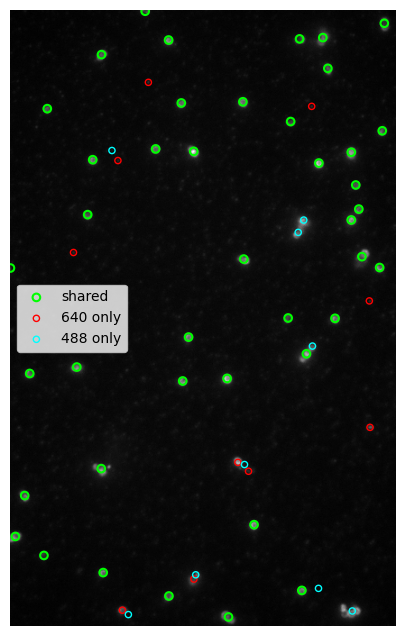


Image name: img_488


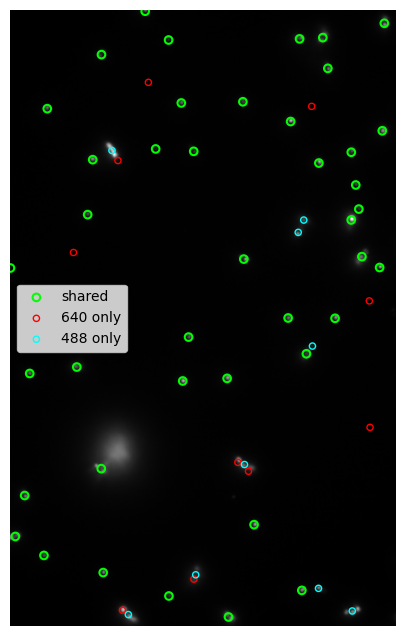

In [9]:
print(f"Image name: img_640")
processUtil.show_label(data[0][0],compared[0])
print(f"\nImage name: img_488")
processUtil.show_label(data[0][1],compared[0])

Todo:
- count num of bateria:
```python
print(f"Segmentation complete.")
print(f"Masks shape: {masks.shape}")
print("Unique mask values:", np.unique(masks))
print("Number of objects:", len(np.unique(masks)) - 1)
```